In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/nigeria.csv")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [2]:
# Add country column
df["Country"] = "Nigeria"

# Convert YEAR + DOY into proper date
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

# Extract month
df["Month"] = df["Date"].dt.month

# Check result
df[["YEAR", "DOY", "Date", "Month", "Country"]].head()

,YEAR,DOY,Date,Month,Country
0,2015,1,2015-01-01,1,Nigeria
1,2015,2,2015-01-02,1,Nigeria
2,2015,3,2015-01-03,1,Nigeria
3,2015,4,2015-01-04,1,Nigeria
4,2015,5,2015-01-05,1,Nigeria


In [ ]:
# Replace -999 with NaN
df.replace(-999, np.nan, inplace=True)

print("Missing values after replacing -999:")
print(df.isna().sum())

print("\n----------------------")

# Check duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Drop duplicates if found
df = df.drop_duplicates()

print("\nDataset shape after removing duplicates:")
print(df.shape)

Missing values after replacing -999:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

----------------------
Number of duplicate rows: 0

Dataset shape after removing duplicates:
(4108, 15)


Data Cleaning
Loaded Nigeria climate dataset successfully.
Replaced invalid -999 values with NaN.
No missing values were found after cleaning.
No duplicate rows were found.
Final dataset contains 4,108 records.
Insight

The Nigeria dataset is clean and ready for further exploratory data analysis.

In [4]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


In [5]:
df.describe(include=[np.number])

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,6.423564
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,3.477046
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,12.000000


Descriptive Statistics
Average temperature: 26.7°C
Maximum temperature: 32.88°C
Minimum temperature: 15.17°C
Average rainfall: 4.21 mm
Average humidity: 85.24%
Maximum wind speed: 6.0 m/s
Insight

Nigeria experiences warm temperatures, very high humidity, and relatively high rainfall, indicating a tropical climate with frequent wet conditions.

In [6]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Percentage Per Column:")
print(missing_percentage)

print("\nColumns with more than 5% missing values:")
print(missing_percentage[missing_percentage > 5])

Missing Percentage Per Column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64

Columns with more than 5% missing values:
Series([], dtype: float64)


Missing Value Analysis
Missing values in all columns: 0%
No column had more than 5% missing values.
Insight

The Nigeria dataset has no missing values, so no additional missing value handling was required.

In [7]:
from scipy.stats import zscore

columns_to_check = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

z_scores = df[columns_to_check].apply(zscore)

outliers = (abs(z_scores) > 3).any(axis=1)

print("Number of outlier rows:")
print(outliers.sum())

Number of outlier rows:
225


Outlier Analysis
Detected 225 outlier rows using the Z-score method.
Insight

These outliers may represent extreme rainfall events, unusual humidity levels, or rare temperature changes. They were retained because they may reflect real climate patterns in Nigeria.

In [8]:
# Drop rows where more than 30% values are missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill remaining missing values
df = df.ffill()

print("Remaining missing values:")
print(df.isna().sum())

Remaining missing values:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


### Missing Value Handling

Dropped rows with more than 30% missing values.
Applied forward fill for remaining missing values.
Final dataset has 0 missing values in all columns.
Insight

The dataset is fully cleaned and ready for further analysis.

In [9]:
df.to_csv("../data/nigeria_clean.csv", index=False)

print("Cleaned Nigeria  dataset exported successfully!")

Cleaned Nigeria  dataset exported successfully!


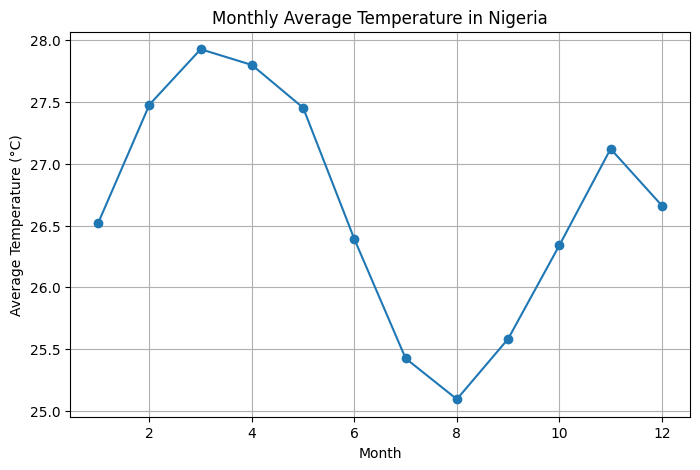

In [10]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(8,5))
monthly_temp.plot(marker="o")
plt.title("Monthly Average Temperature in Nigeria")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

### Monthly Temperature Trend Interpretation

Temperature increases from January to March.
March (Month 3) is the warmest month at approximately 27.9°C.
Temperature decreases from April to August.
August (Month 8) is the coolest month at approximately 25.1°C.
Temperature rises again from September to November before slightly dropping in December.
Insight

Nigeria experiences warm temperatures throughout the year, with hotter conditions early in the year and cooler temperatures during the mid-year rainy season.

In [11]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

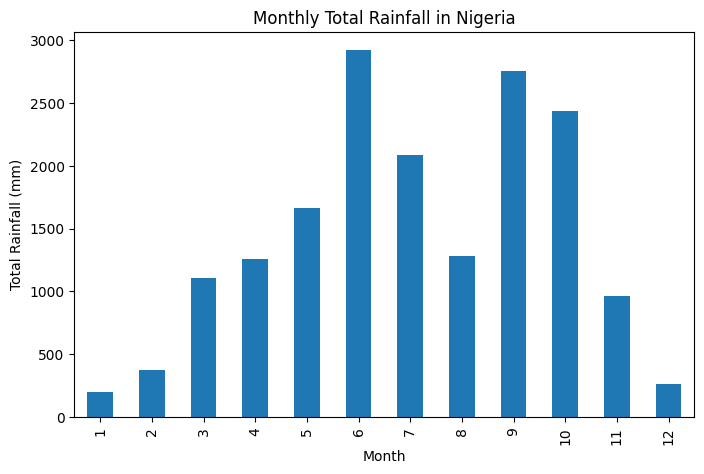

In [12]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(8,5))
monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall in Nigeria")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.show()

### Rainfall Trend Interpretation
 
 Rainfall increases from January to June.
June (Month 6) records the highest rainfall.
Rainfall remains high in July and September–October.
Rainfall decreases significantly in November and December.
January and December are the driest months.
Insight

Nigeria experiences a long rainy season, with peak rainfall occurring in the middle of the year and drier conditions at the beginning and end of the year.


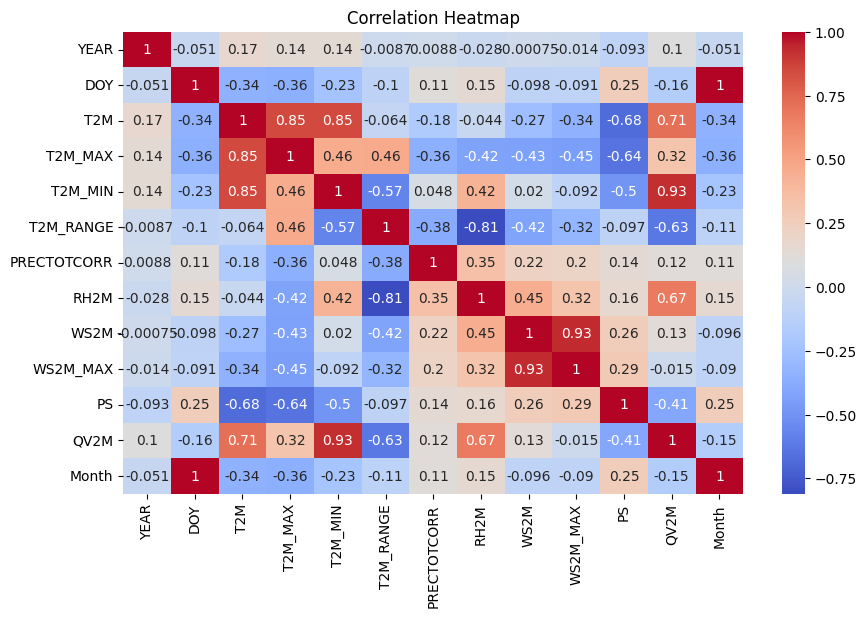

In [13]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Interpretation

T2M and T2M_MAX = 0.85
Higher average temperature is strongly associated with higher maximum temperature.
T2M and T2M_MIN = 0.85
Average temperature also increases with minimum temperature.
WS2M and WS2M_MAX = 0.93
Wind speed has a very strong positive relationship with maximum wind speed.
T2M_MIN and QV2M = 0.93
Higher minimum temperatures are associated with higher moisture levels in the air.
Insight

The heatmap shows strong relationships among temperature, wind, and humidity variables, which is expected in Nigeria’s tropical climate system

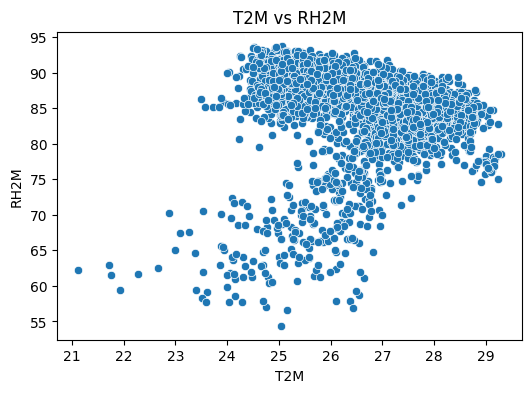

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

### Scatter Plot Interpretation: Temperature vs Humidity

The scatter plot shows a negative relationship between temperature and humidity.
As temperature increases, humidity tends to decrease slightly.
Most observations are concentrated between 24°C–29°C temperature and 80%–93% humidity.
A few lower humidity values appear as outliers.
Insight

Nigeria generally experiences warm temperatures with high humidity, showing typical tropical climate conditions.

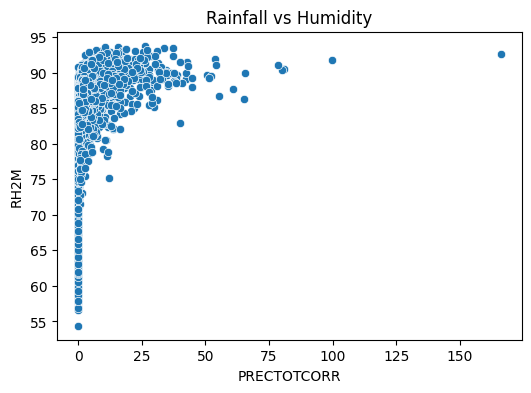

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="PRECTOTCORR", y="RH2M")
plt.title("Rainfall vs Humidity")
plt.show()

### Scatter Plot Interpretation: Rainfall vs Humidity

The scatter plot shows a positive relationship between rainfall and humidity.
Higher rainfall events mostly occur when humidity is above 80%.
Most rainfall values are concentrated at lower levels, with a few extreme rainfall events.
Some outliers represent very heavy rainfall days.
Insight

Rainfall in Nigeria is strongly associated with high humidity, which reflects the country’s wet tropical climate patterns

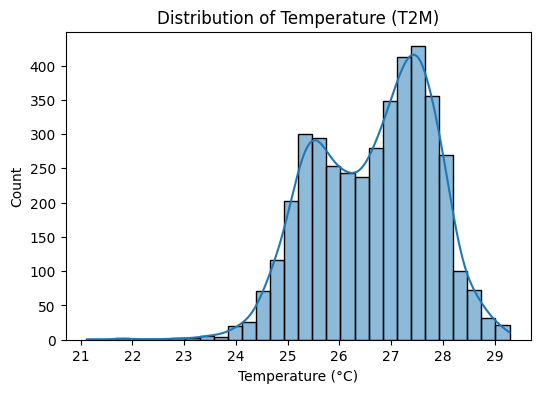

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df["T2M"], bins=30, kde=True)
plt.title("Distribution of Temperature (T2M)")
plt.xlabel("Temperature (°C)")
plt.show()

### Temperature Distribution Interpretation

The temperature distribution is slightly bimodal, with most values concentrated between 25°C and 29°C.
Most observations fall around 27°C–28°C.
Very low and very high temperatures occur less frequently.
Insight

Nigeria experiences consistently warm temperatures throughout the year with small temperature variations.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

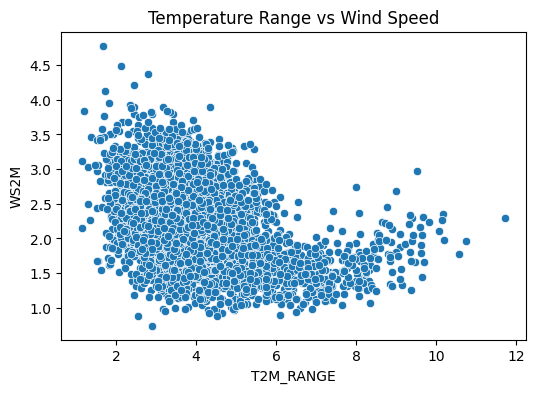

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.show()

### Temperature Range vs Wind Speed Insight

The scatter plot shows a weak negative relationship between temperature range and wind speed.
Higher wind speeds are mostly observed at lower temperature ranges.
Most data points are concentrated between 2–6°C temperature range and 1–3 m/s wind speed.
A few outliers show unusually high wind speeds.
Insight

Nigeria generally experiences moderate wind speeds, and larger temperature variations do not strongly increase wind speed.

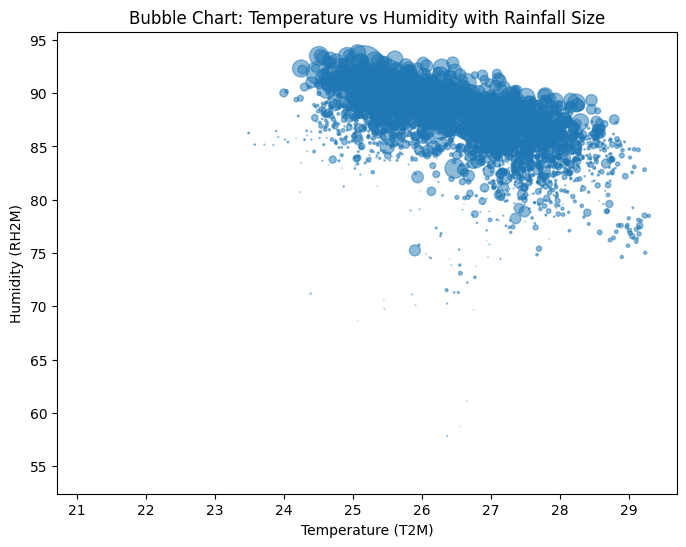

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*5,
    alpha=0.5
)

plt.title("Bubble Chart: Temperature vs Humidity with Rainfall Size")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

### Bubble Chart Insight

The chart shows a negative relationship between temperature and humidity.


As temperature increases, humidity slightly decreases.


Larger bubbles represent higher rainfall amounts.


Most large rainfall events occur when humidity is very high (85%–93%) and temperatures are moderate (25°C–28°C).


Few large rainfall events occur at very high temperatures.


Insight
Nigeria’s rainfall is more likely during highly humid conditions, while hotter temperatures are associated with lower humidity and less rainfall.

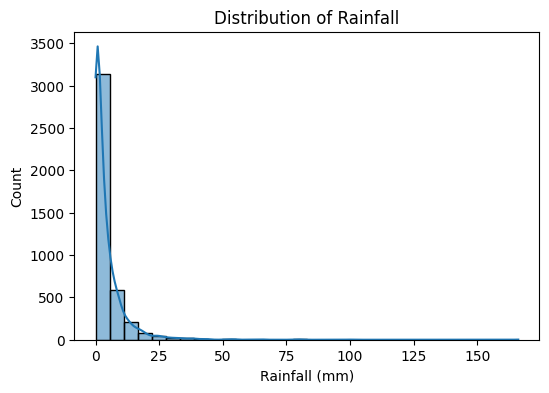

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.show()

### Rainfall Distribution Interpretation

The rainfall distribution is highly right-skewed.
Most days recorded low or no rainfall (close to 0 mm).
A few days experienced very heavy rainfall, reaching over 150 mm.
Extreme rainfall events are rare but present as outliers.
Insight

Nigeria experiences frequent low-rainfall days, but occasional heavy rainfall events contribute significantly to total annual rainfall.

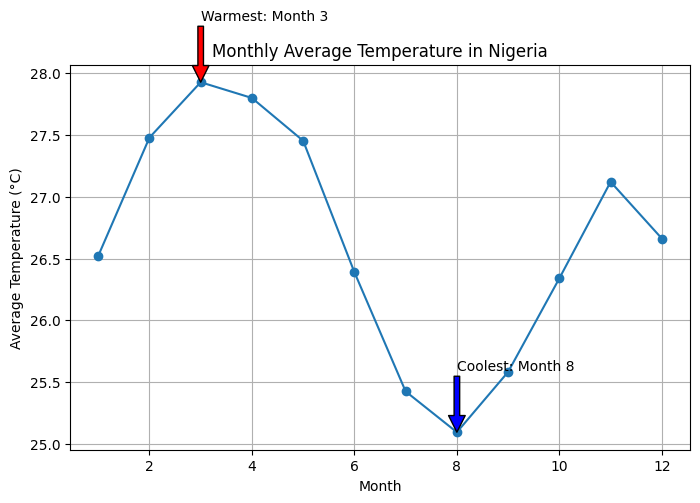

In [21]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")

# Find warmest month
warmest_month = monthly_temp.idxmax()
warmest_temp = monthly_temp.max()

# Find coolest month
coolest_month = monthly_temp.idxmin()
coolest_temp = monthly_temp.min()

# Annotate warmest month
plt.annotate(
    f"Warmest: Month {warmest_month}",
    xy=(warmest_month, warmest_temp),
    xytext=(warmest_month, warmest_temp+0.5),
    arrowprops=dict(facecolor='red')
)

# Annotate coolest month
plt.annotate(
    f"Coolest: Month {coolest_month}",
    xy=(coolest_month, coolest_temp),
    xytext=(coolest_month, coolest_temp+0.5),
    arrowprops=dict(facecolor='blue')
)

plt.title("Monthly Average Temperature in Nigeria")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

### Monthly Temperature Trend Interpretation

Temperature increases from January to March.
March (Month 3) is the warmest month at approximately 27.9°C.
Temperature decreases from April to August.
August (Month 8) is the coolest month at approximately 25.1°C.
Temperature rises again from September to November and slightly drops in December.
Insight

Nigeria remains warm throughout the year, with hotter months early in the year and cooler temperatures during the peak rainy season.

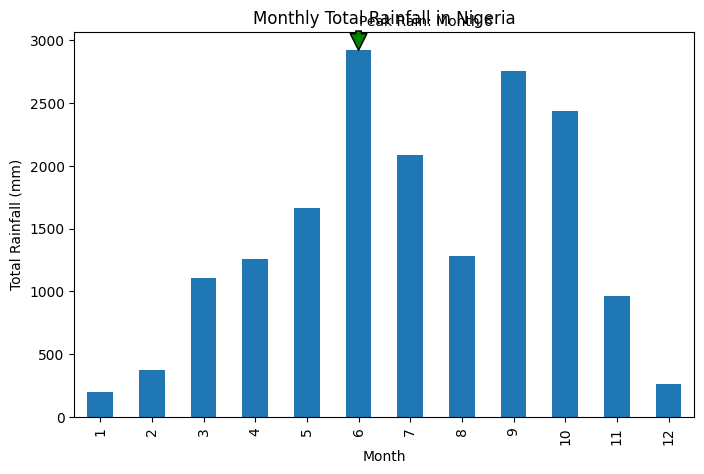

In [22]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(8,5))
monthly_rain.plot(kind="bar")

# Peak rainfall month
peak_month = monthly_rain.idxmax()
peak_rain = monthly_rain.max()

plt.annotate(
    f"Peak Rain: Month {peak_month}",
    xy=(peak_month-1, peak_rain),
    xytext=(peak_month-1, peak_rain+200),
    arrowprops=dict(facecolor='green')
)

plt.title("Monthly Total Rainfall in Nigeria")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.show()

### Monthly Rainfall Trend Interpretation

Rainfall increases from January to June.
June (Month 6) records the highest rainfall.
Rainfall remains high in July, September, and October.
Rainfall decreases in November and December.
January and December are the driest months.
Insight

Nigeria has a long rainy season, with peak rainfall occurring mid-year and drier conditions at the beginning and end of the year.

# Final EDA Summary

## Data Cleaning

- Loaded Nigeria climate dataset successfully.
Replaced invalid -999 values with NaN.
No missing values remained after cleaning.
No duplicate rows were found.
Dataset contains 4,108 records.

## Descriptive Statistics
Average temperature: ~26.7°C
Average humidity: ~85%
Average rainfall: ~4.21 mm
Temperature ranges from ~21°C to ~29°C.

## Outlier Analysis
Detected 225 outlier rows using the Z-score method.
These likely represent extreme rainfall and weather conditions.

## Monthly Trends
Temperature peaks in March.
Temperature is lowest in August.
Rainfall peaks in June.
January and December are the driest months.

## Correlation Insights
Strong positive relationship between T2M and T2M_MAX (0.85).
Strong positive relationship between T2M and T2M_MIN (0.85).
Strong positive relationship between WS2M and WS2M_MAX (0.93).

## Distribution Insights
Temperature distribution is slightly bimodal but mostly concentrated between 25°C–29°C.
Rainfall distribution is highly right-skewed with a few extreme rainfall events.

## Conclusion
Nigeria has a warm and humid tropical climate with heavy seasonal rainfall.
The dataset is clean and suitable for climate analysis.